# Adult Income Prediction — Modelling Pipeline
## Work Plan 4: Baseline & Symbolic Models + Evaluation Setup
## Work Plan 6: Advanced Models, Ensemble & Interpretation


In [1]:
# =============================================================================
# STEP 0: Imports
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.labelsize": 10})


---
## STEP 1 — Load Preprocessed Data
Load the train/val/test splits saved by `EDA_Preprocessing.ipynb`.


In [2]:
# =============================================================================
# STEP 1 — Load Preprocessed Data
# =============================================================================
# NOTE: You must run EDA_Preprocessing.ipynb first (including the save cell)
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test  = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class distribution:")
print(pd.Series(y_train).value_counts(normalize=True).to_string())


Train: (32542, 41), Test: (16248, 41)
Train class distribution:
0    0.760586
1    0.239414


---
## STEP 2 — Reusable Evaluation Function
Primary metric: **F1-Score (weighted)**. Secondary: ROC-AUC, Accuracy, Precision, Recall.


In [3]:
# =============================================================================
# STEP 2 — Evaluation Helper
# =============================================================================
all_results = []  # collect results for final comparison

def evaluate_model(model, X_test, y_test, model_name="Model"):
    """Evaluate a fitted model and print all required metrics."""
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
    else:
        y_proba = y_pred

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec  = recall_score(y_test, y_pred, average="weighted")
    f1   = f1_score(y_test, y_pred, average="weighted")
    auc  = roc_auc_score(y_test, y_proba)

    print(f"\n{'='*60}")
    print(f"  Evaluation: {model_name}")
    print(f"{'='*60}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}  << PRIMARY")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"\nClassification Report:\n")
    print(classification_report(y_test, y_pred, target_names=["<=50K", ">50K"]))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["<=50K", ">50K"],
        cmap="Blues", ax=axes[0])
    axes[0].set_title(f"{model_name} - Confusion Matrix")
    RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
    axes[1].set_title(f"{model_name} - ROC Curve")
    plt.tight_layout()
    plt.show()

    result = {"Model": model_name, "Accuracy": acc, "Precision": prec,
              "Recall": rec, "F1-Score": f1, "ROC-AUC": auc}
    all_results.append(result)
    return result


---
# WORK PLAN 4 — Baseline & Symbolic Models
## STEP 3 — Majority-Class Baseline



  Evaluation: Majority-Class Baseline
  Accuracy : 0.7606
  Precision: 0.5785
  Recall   : 0.7606
  F1-Score : 0.6572  << PRIMARY
  ROC-AUC  : 0.5000

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.76      1.00      0.86     12358
        >50K       0.00      0.00      0.00      3890

    accuracy                           0.76     16248
   macro avg       0.38      0.50      0.43     16248
weighted avg       0.58      0.76      0.66     16248



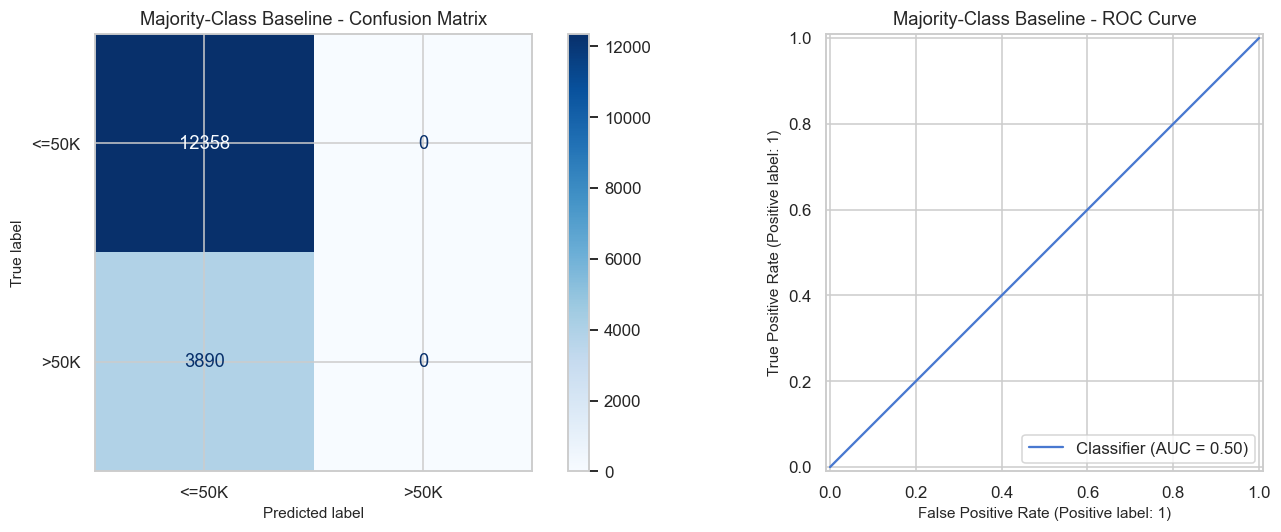

{'Model': 'Majority-Class Baseline',
 'Accuracy': 0.7605859182668636,
 'Precision': np.float64(0.5784909390658481),
 'Recall': np.float64(0.7605859182668636),
 'F1-Score': np.float64(0.6571572941300358),
 'ROC-AUC': np.float64(0.5)}

In [4]:
# =============================================================================
# STEP 3 — Majority-Class Baseline
# =============================================================================
baseline = DummyClassifier(strategy="most_frequent", random_state=42)
baseline.fit(X_train, y_train)
evaluate_model(baseline, X_test, y_test, "Majority-Class Baseline")


---
## STEP 4 — Logistic Regression + Coefficient Analysis



  Evaluation: Logistic Regression
  Accuracy : 0.8458
  Precision: 0.8389
  Recall   : 0.8458
  F1-Score : 0.8404  << PRIMARY
  ROC-AUC  : 0.8990

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90     12358
        >50K       0.72      0.59      0.65      3890

    accuracy                           0.85     16248
   macro avg       0.80      0.76      0.77     16248
weighted avg       0.84      0.85      0.84     16248



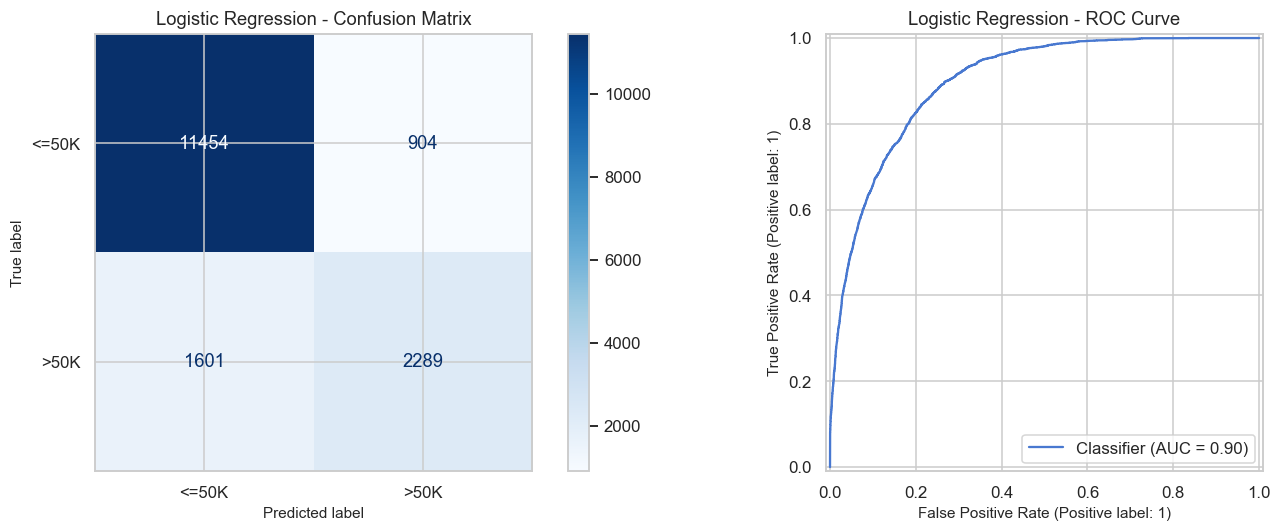

{'Model': 'Logistic Regression',
 'Accuracy': 0.8458271787296898,
 'Precision': np.float64(0.8389427886823384),
 'Recall': np.float64(0.8458271787296898),
 'F1-Score': np.float64(0.8403557608040607),
 'ROC-AUC': np.float64(0.8990244966885516)}

In [5]:
# =============================================================================
# STEP 4a — Logistic Regression
# =============================================================================
lr_model = LogisticRegression(max_iter=1000, random_state=42, solver="lbfgs")
lr_model.fit(X_train, y_train)
evaluate_model(lr_model, X_test, y_test, "Logistic Regression")


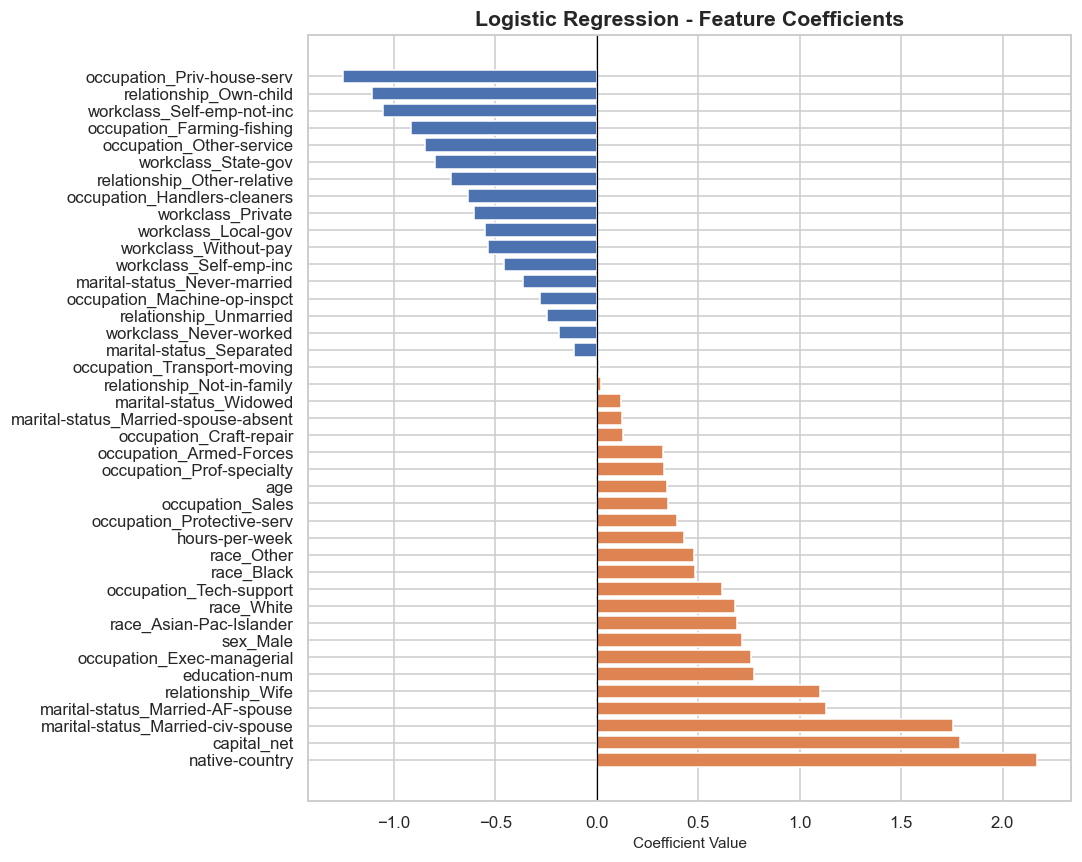


Top 5 features pushing towards >50K:
                          Feature  Coefficient
                   native-country     2.168143
                      capital_net     1.788260
marital-status_Married-civ-spouse     1.757444
 marital-status_Married-AF-spouse     1.127929
                relationship_Wife     1.101391

Top 5 features pushing towards <=50K:
                   Feature  Coefficient
  occupation_Other-service    -0.848147
occupation_Farming-fishing    -0.917399
workclass_Self-emp-not-inc    -1.056406
    relationship_Own-child    -1.106671
occupation_Priv-house-serv    -1.251339


In [6]:
# =============================================================================
# STEP 4b — Coefficient Analysis (required by work plan)
# =============================================================================
coeffs = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_[0]
}).sort_values("Coefficient", ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#DD8452" if c > 0 else "#4C72B0" for c in coeffs["Coefficient"]]
ax.barh(coeffs["Feature"], coeffs["Coefficient"], color=colors, edgecolor="white")
ax.set_title("Logistic Regression - Feature Coefficients", fontsize=14, fontweight="bold")
ax.set_xlabel("Coefficient Value")
ax.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nTop 5 features pushing towards >50K:")
print(coeffs.head(5).to_string(index=False))
print("\nTop 5 features pushing towards <=50K:")
print(coeffs.tail(5).to_string(index=False))


---
## STEP 5 — Decision Tree (max_depth=5) + Visualization



  Evaluation: Decision Tree (depth=5)
  Accuracy : 0.8508
  Precision: 0.8436
  Recall   : 0.8508
  F1-Score : 0.8434  << PRIMARY
  ROC-AUC  : 0.8826

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.87      0.94      0.91     12358
        >50K       0.75      0.57      0.65      3890

    accuracy                           0.85     16248
   macro avg       0.81      0.75      0.78     16248
weighted avg       0.84      0.85      0.84     16248



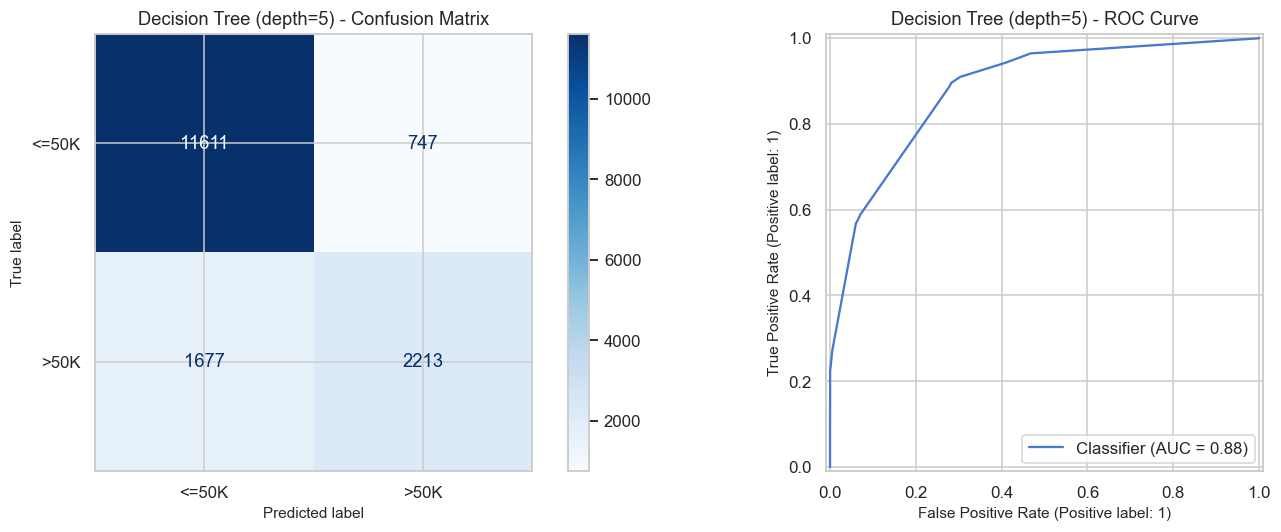

{'Model': 'Decision Tree (depth=5)',
 'Accuracy': 0.8508124076809453,
 'Precision': np.float64(0.8435912409540034),
 'Recall': np.float64(0.8508124076809453),
 'F1-Score': np.float64(0.8433900669899114),
 'ROC-AUC': np.float64(0.8825534680656058)}

In [7]:
# =============================================================================
# STEP 5a — Decision Tree (max_depth=5 per work plan)
# =============================================================================
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
evaluate_model(dt_model, X_test, y_test, "Decision Tree (depth=5)")


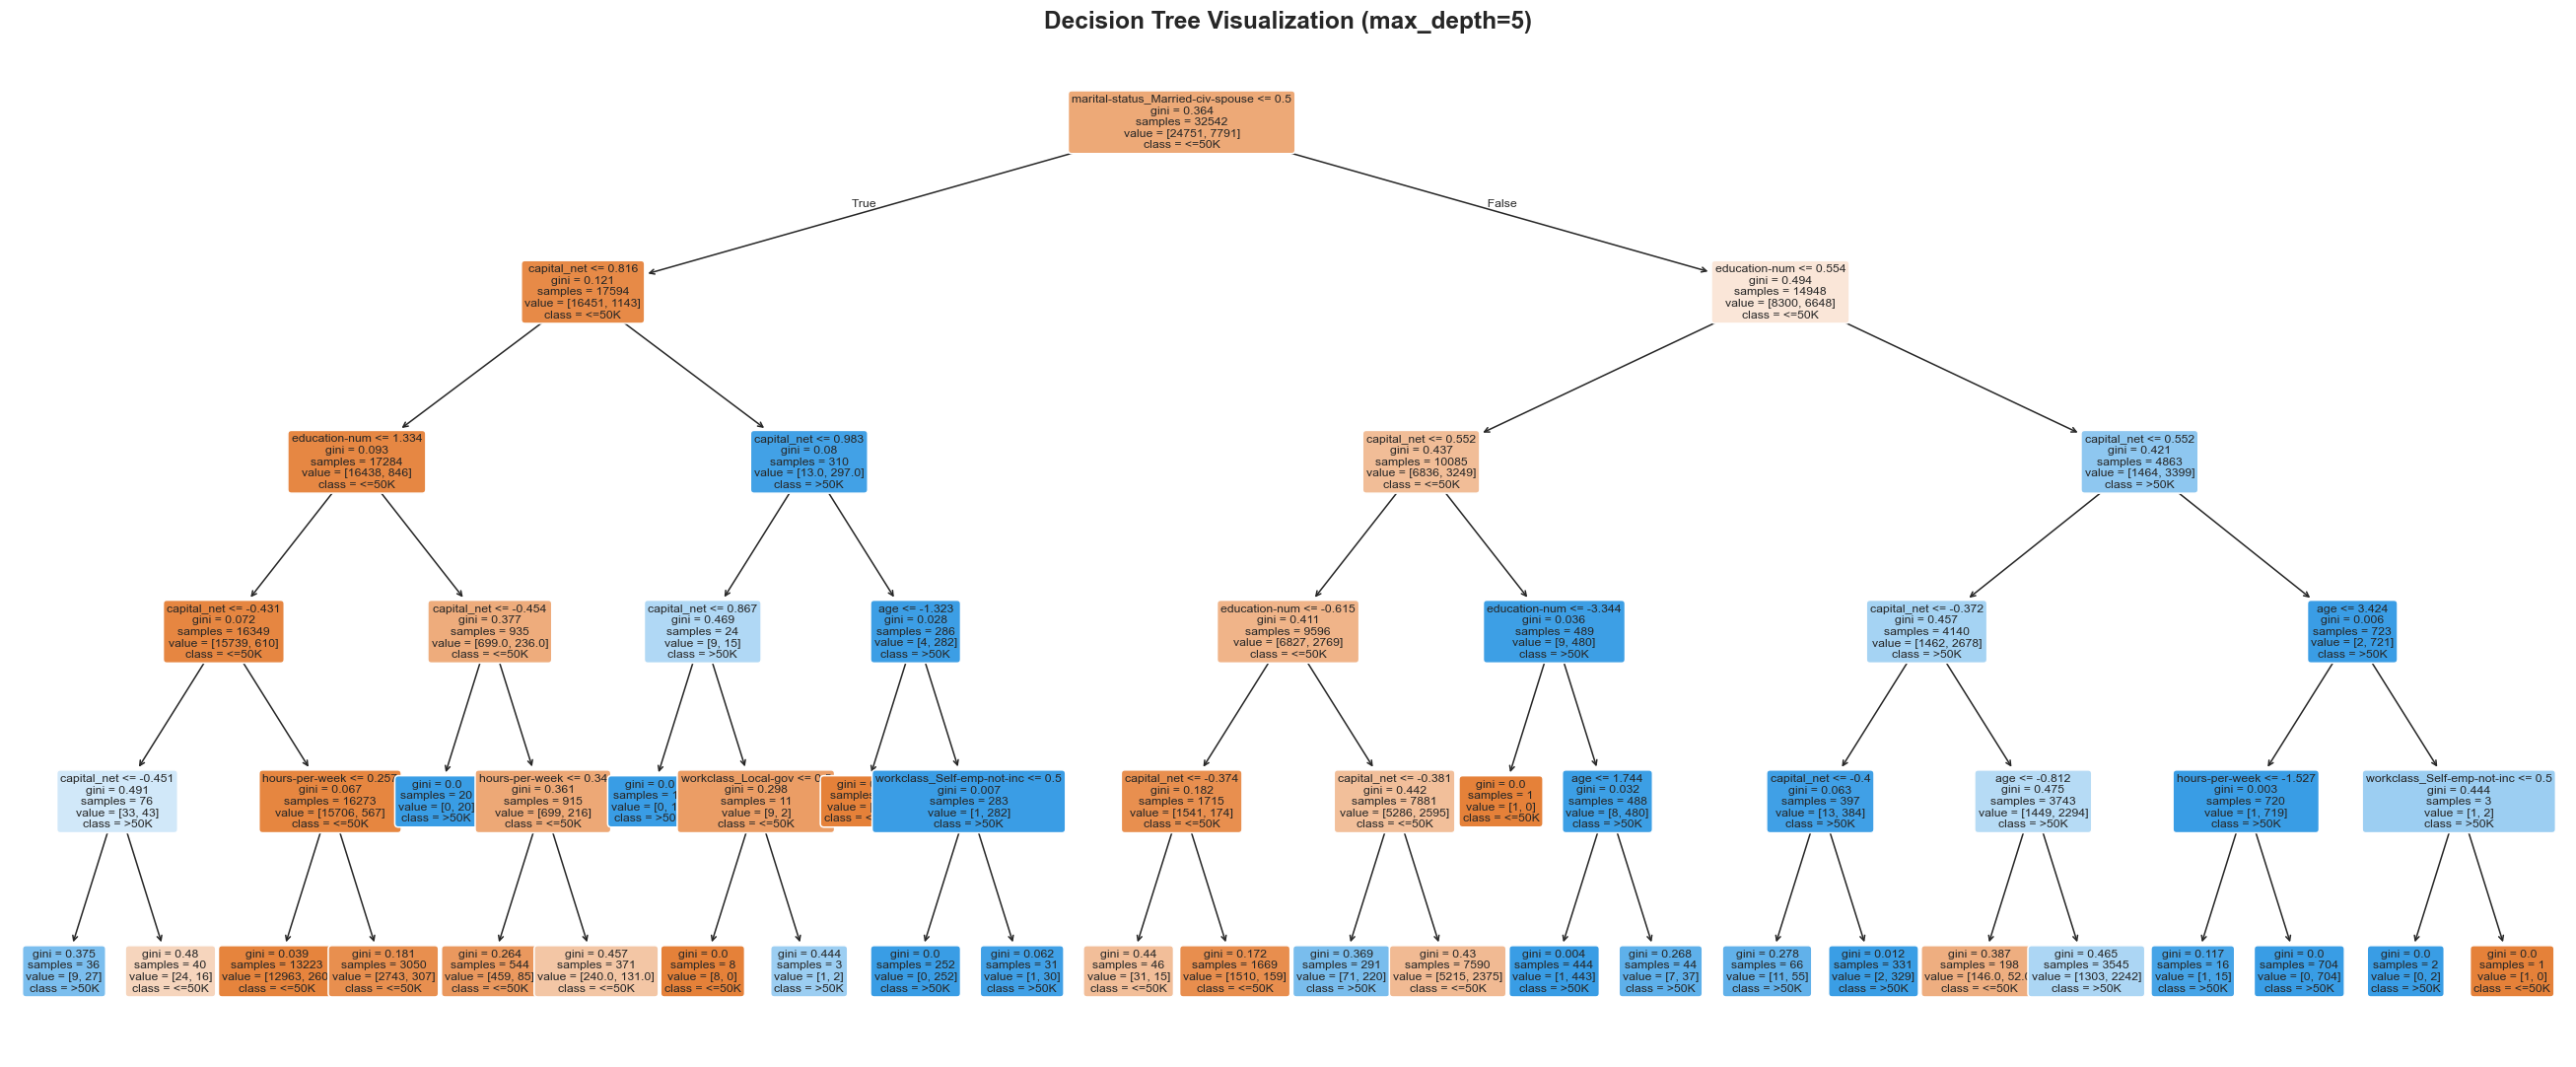

In [8]:
# =============================================================================
# STEP 5b — Tree Visualization (required by work plan)
# =============================================================================
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(dt_model, feature_names=X_train.columns.tolist(),
          class_names=["<=50K", ">50K"], filled=True, rounded=True,
          fontsize=8, ax=ax)
ax.set_title("Decision Tree Visualization (max_depth=5)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


---
## STEP 6 — Work Plan 4 Results Summary


In [9]:
# =============================================================================
# STEP 6 — WP4 Results Summary
# =============================================================================
wp4_df = pd.DataFrame(all_results).set_index("Model")
print("\n" + "="*70)
print("  WORK PLAN 4 — MODEL COMPARISON SUMMARY")
print("="*70)
print(wp4_df.round(4).to_string())
print("\nPrimary metric: F1-Score (weighted)")



  WORK PLAN 4 — MODEL COMPARISON SUMMARY
                         Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                  
Majority-Class Baseline    0.7606     0.5785  0.7606    0.6572   0.5000
Logistic Regression        0.8458     0.8389  0.8458    0.8404   0.8990
Decision Tree (depth=5)    0.8508     0.8436  0.8508    0.8434   0.8826

Primary metric: F1-Score (weighted)


---
# WORK PLAN 6 — Advanced Models, Ensemble & Interpretation


## STEP 7 — SVM (RBF Kernel)
> Note: SVM can be slow on large datasets. Be patient.



  Evaluation: SVM (RBF kernel)
  Accuracy : 0.8557
  Precision: 0.8492
  Recall   : 0.8557
  F1-Score : 0.8494  << PRIMARY
  ROC-AUC  : 0.8965

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91     12358
        >50K       0.75      0.59      0.66      3890

    accuracy                           0.86     16248
   macro avg       0.82      0.77      0.79     16248
weighted avg       0.85      0.86      0.85     16248



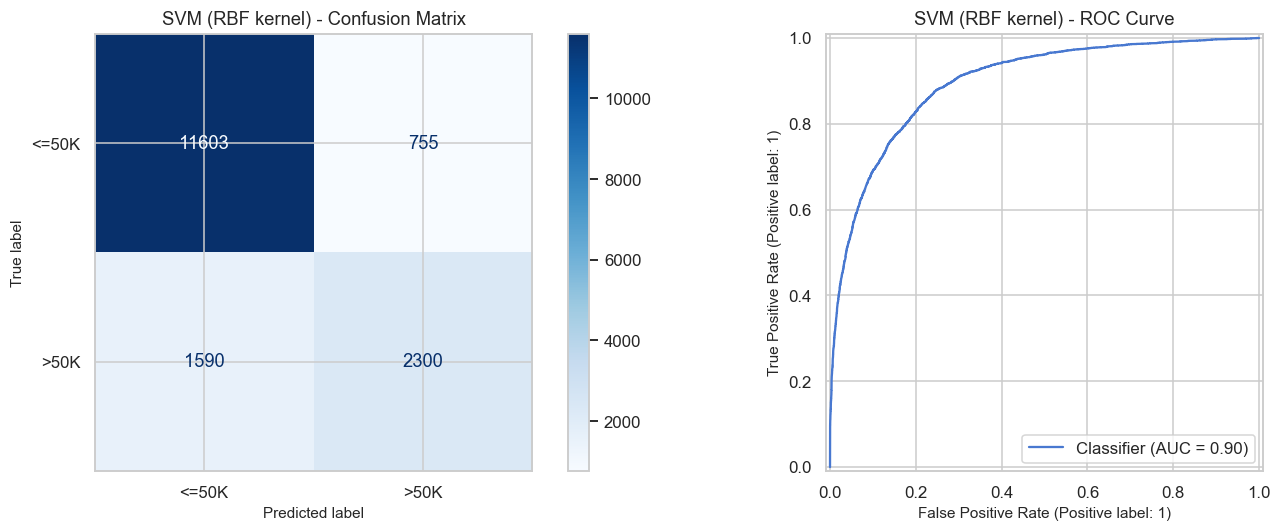

{'Model': 'SVM (RBF kernel)',
 'Accuracy': 0.8556745445593303,
 'Precision': np.float64(0.8491675580125041),
 'Recall': np.float64(0.8556745445593303),
 'F1-Score': np.float64(0.8493566513462484),
 'ROC-AUC': np.float64(0.8965335049348256)}

In [10]:
# =============================================================================
# STEP 7 — SVM (RBF kernel)
# =============================================================================
svm_model = SVC(kernel="rbf", probability=True, random_state=42)
svm_model.fit(X_train, y_train)
evaluate_model(svm_model, X_test, y_test, "SVM (RBF kernel)")


---
## STEP 8 — Random Forest (n_estimators=200)



  Evaluation: Random Forest (n=200)
  Accuracy : 0.8472
  Precision: 0.8420
  Recall   : 0.8472
  F1-Score : 0.8437  << PRIMARY
  ROC-AUC  : 0.8955

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90     12358
        >50K       0.71      0.62      0.66      3890

    accuracy                           0.85     16248
   macro avg       0.80      0.77      0.78     16248
weighted avg       0.84      0.85      0.84     16248



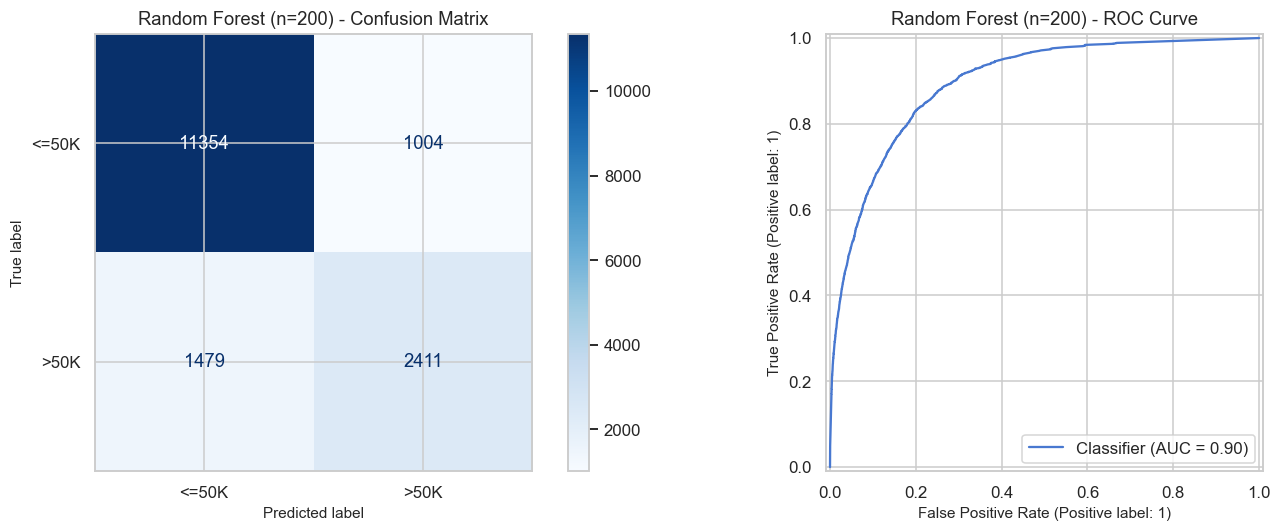

{'Model': 'Random Forest (n=200)',
 'Accuracy': 0.8471811915312654,
 'Precision': np.float64(0.8419556265772444),
 'Recall': np.float64(0.8471811915312654),
 'F1-Score': np.float64(0.843653520966063),
 'ROC-AUC': np.float64(0.895474357336879)}

In [11]:
# =============================================================================
# STEP 8 — Random Forest (n_estimators=200 per work plan)
# =============================================================================
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
evaluate_model(rf_model, X_test, y_test, "Random Forest (n=200)")


---
## STEP 9 — XGBoost (n_estimators=300)



  Evaluation: XGBoost (n=300)
  Accuracy : 0.8695
  Precision: 0.8654
  Recall   : 0.8695
  F1-Score : 0.8665  << PRIMARY
  ROC-AUC  : 0.9245

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.90      0.93      0.92     12358
        >50K       0.76      0.67      0.71      3890

    accuracy                           0.87     16248
   macro avg       0.83      0.80      0.81     16248
weighted avg       0.87      0.87      0.87     16248



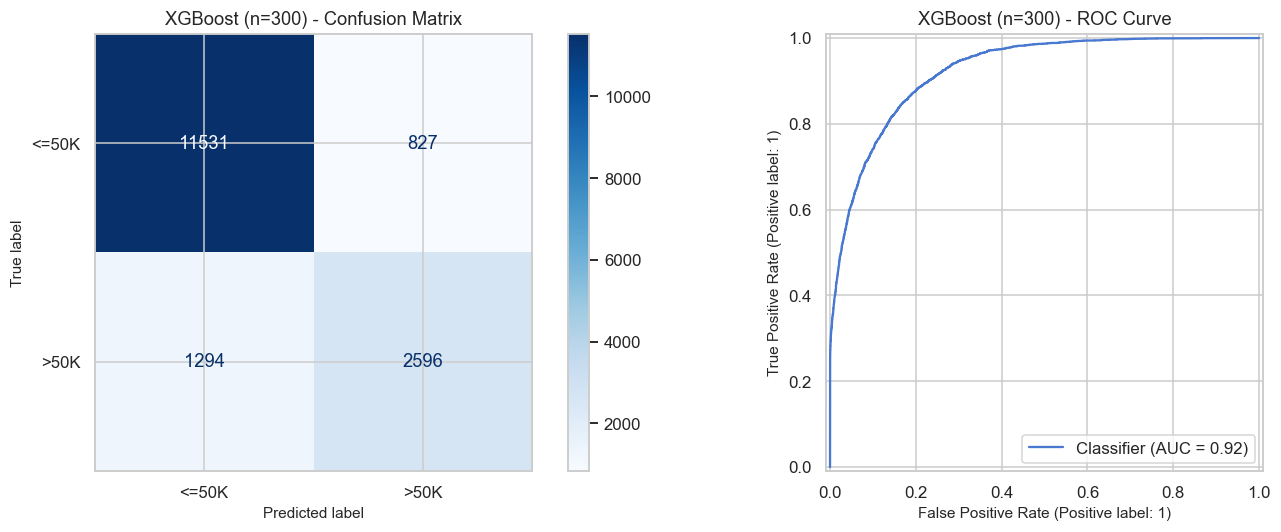

{'Model': 'XGBoost (n=300)',
 'Accuracy': 0.8694608567208272,
 'Precision': np.float64(0.8654167353434603),
 'Recall': np.float64(0.8694608567208272),
 'F1-Score': np.float64(0.8665031905320745),
 'ROC-AUC': np.float64(0.9245252703097937)}

In [12]:
# =============================================================================
# STEP 9 — XGBoost (n_estimators=300 per work plan)
# =============================================================================
xgb_model = XGBClassifier(
    n_estimators=300, random_state=42,
    use_label_encoder=False, eval_metric="logloss", n_jobs=-1)
xgb_model.fit(X_train, y_train)
evaluate_model(xgb_model, X_test, y_test, "XGBoost (n=300)")


---
## STEP 10 — Soft Voting Ensemble (LR + RF + XGBoost)



  Evaluation: Soft Voting Ensemble (LR+RF+XGB)
  Accuracy : 0.8651
  Precision: 0.8603
  Recall   : 0.8651
  F1-Score : 0.8613  << PRIMARY
  ROC-AUC  : 0.9206

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91     12358
        >50K       0.76      0.64      0.70      3890

    accuracy                           0.87     16248
   macro avg       0.82      0.79      0.80     16248
weighted avg       0.86      0.87      0.86     16248



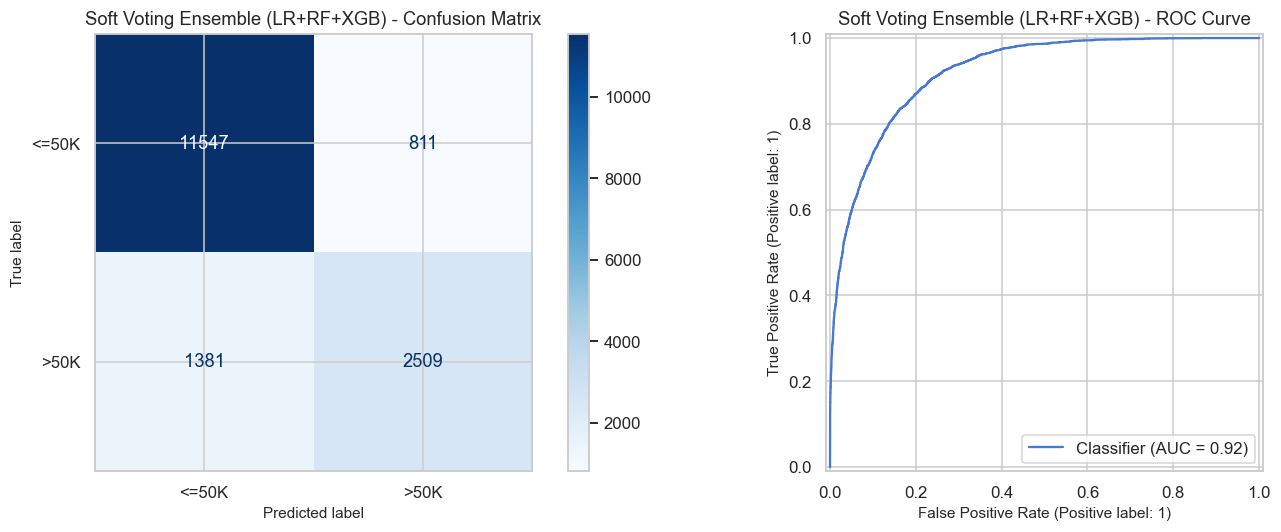

{'Model': 'Soft Voting Ensemble (LR+RF+XGB)',
 'Accuracy': 0.8650910881339242,
 'Precision': np.float64(0.860269006447386),
 'Recall': np.float64(0.8650910881339242),
 'F1-Score': np.float64(0.8612789166028473),
 'ROC-AUC': np.float64(0.9205918046488833)}

In [13]:
# =============================================================================
# STEP 10 — Soft Voting Ensemble
# =============================================================================
ensemble_model = VotingClassifier(
    estimators=[
        ("lr", LogisticRegression(max_iter=1000, random_state=42, solver="lbfgs")),
        ("rf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
        ("xgb", XGBClassifier(n_estimators=300, random_state=42,
                              use_label_encoder=False, eval_metric="logloss", n_jobs=-1))
    ],
    voting="soft"
)
ensemble_model.fit(X_train, y_train)
evaluate_model(ensemble_model, X_test, y_test, "Soft Voting Ensemble (LR+RF+XGB)")


---
## STEP 11 — Feature Importance Analysis (Gini for RF, Gain for XGBoost)


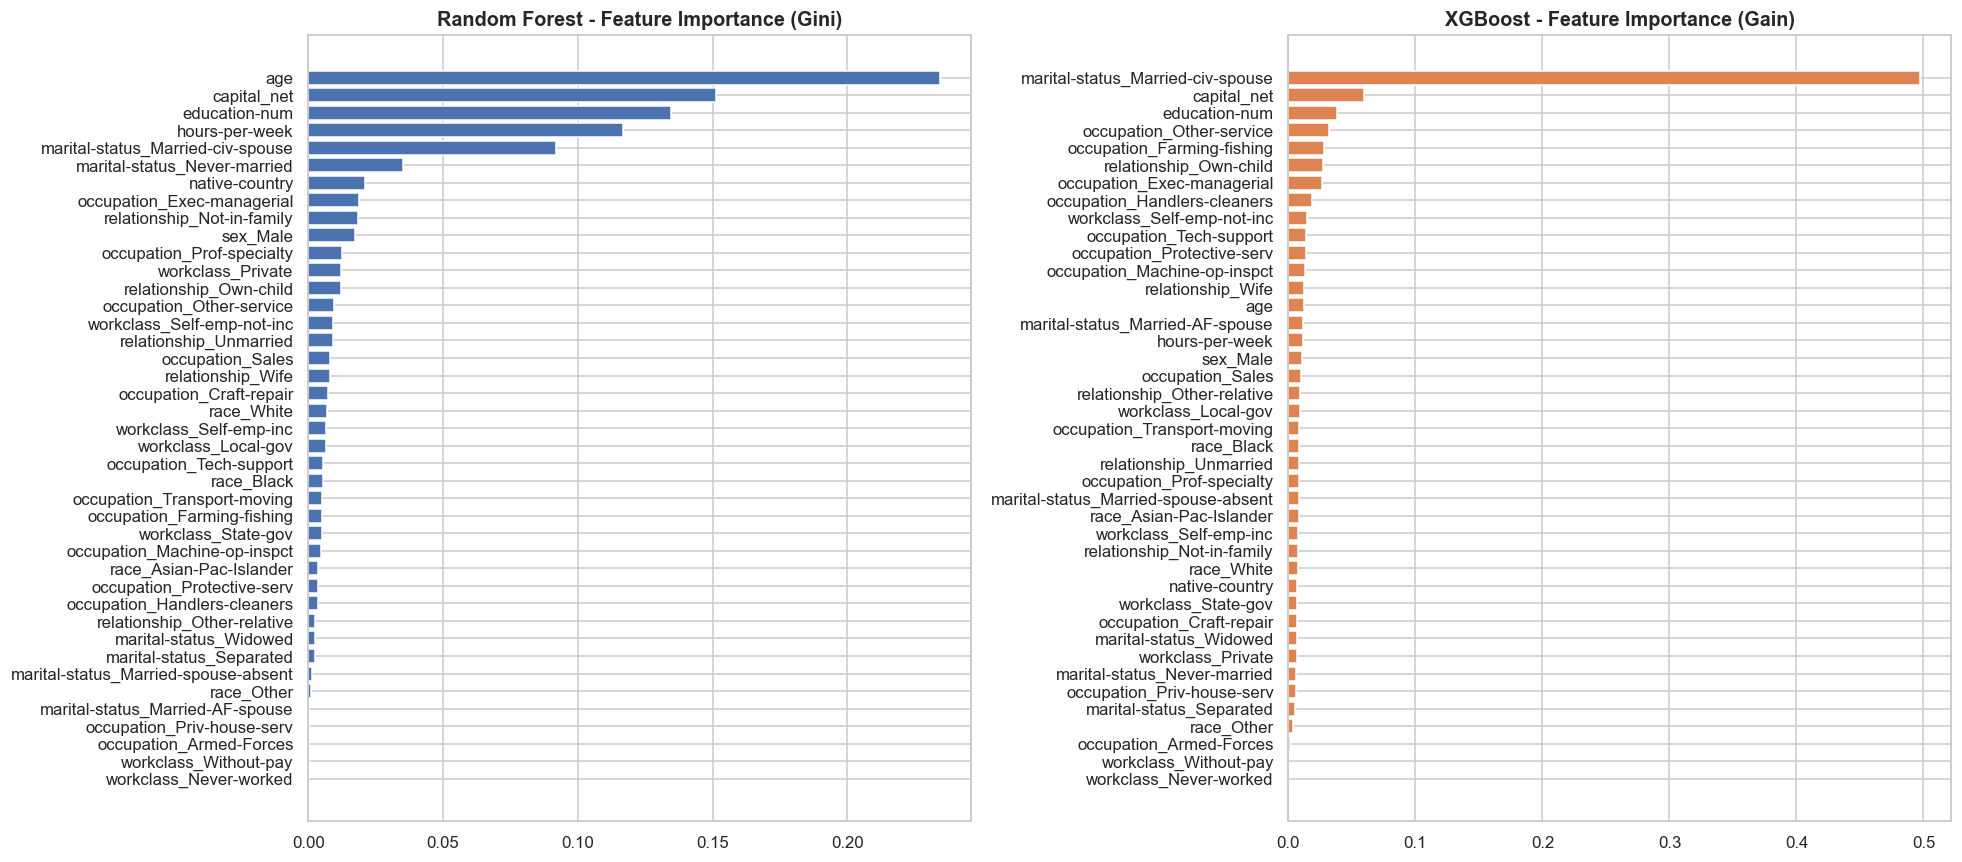


Top 5 Features (Random Forest - Gini):
                          Feature  Importance (Gini)
                              age           0.234302
                      capital_net           0.151366
                    education-num           0.134450
                   hours-per-week           0.116802
marital-status_Married-civ-spouse           0.092040

Top 5 Features (XGBoost - Gain):
                          Feature  Importance (Gain)
marital-status_Married-civ-spouse           0.497117
                      capital_net           0.059660
                    education-num           0.038606
         occupation_Other-service           0.032113
       occupation_Farming-fishing           0.028396


In [14]:
# =============================================================================
# STEP 11 — Feature Importance
# =============================================================================
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance (Gini)": rf_model.feature_importances_
}).sort_values("Importance (Gini)", ascending=False)

xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance (Gain)": xgb_model.feature_importances_
}).sort_values("Importance (Gain)", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].barh(rf_importance["Feature"], rf_importance["Importance (Gini)"],
             color="#4C72B0", edgecolor="white")
axes[0].set_title("Random Forest - Feature Importance (Gini)", fontsize=13, fontweight="bold")
axes[0].invert_yaxis()

axes[1].barh(xgb_importance["Feature"], xgb_importance["Importance (Gain)"],
             color="#DD8452", edgecolor="white")
axes[1].set_title("XGBoost - Feature Importance (Gain)", fontsize=13, fontweight="bold")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 5 Features (Random Forest - Gini):")
print(rf_importance.head(5).to_string(index=False))
print("\nTop 5 Features (XGBoost - Gain):")
print(xgb_importance.head(5).to_string(index=False))


---
## STEP 12 — Decision Tree Rule Extraction


In [15]:
# =============================================================================
# STEP 12 — Decision Tree Rules
# =============================================================================
tree_rules = export_text(dt_model, feature_names=X_train.columns.tolist())
print("Decision Tree Rules (max_depth=5):")
print(tree_rules)


Decision Tree Rules (max_depth=5):
|--- marital-status_Married-civ-spouse <= 0.50
|   |--- capital_net <= 0.82
|   |   |--- education-num <= 1.33
|   |   |   |--- capital_net <= -0.43
|   |   |   |   |--- capital_net <= -0.45
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- capital_net >  -0.45
|   |   |   |   |   |--- class: 0
|   |   |   |--- capital_net >  -0.43
|   |   |   |   |--- hours-per-week <= 0.26
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- hours-per-week >  0.26
|   |   |   |   |   |--- class: 0
|   |   |--- education-num >  1.33
|   |   |   |--- capital_net <= -0.45
|   |   |   |   |--- class: 1
|   |   |   |--- capital_net >  -0.45
|   |   |   |   |--- hours-per-week <= 0.34
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- hours-per-week >  0.34
|   |   |   |   |   |--- class: 0
|   |--- capital_net >  0.82
|   |   |--- capital_net <= 0.98
|   |   |   |--- capital_net <= 0.87
|   |   |   |   |--- class: 1
|   |   |   |--- capital_net >  0.87
|   |  

---
## STEP 13 — Fairness Analysis Across Protected Attributes
Analyzing model performance across `sex`, `race` groups.


In [16]:
# =============================================================================
# STEP 13 — Fairness Analysis
# =============================================================================
# We analyze fairness using the encoded features available in X_test.
# sex_Male=True means Male, sex_Male=False means Female
# race columns: race_White, race_Black, race_Asian-Pac-Islander, race_Other

def fairness_analysis(model, X_test_df, y_test_arr, group_col, model_name):
    """Analyze model fairness across a binary group column."""
    y_pred = model.predict(X_test_df)
    results = []
    for val in [True, False]:
        mask = X_test_df[group_col] == val
        if mask.sum() < 10:
            continue
        g_f1 = f1_score(y_test_arr[mask], y_pred[mask], average="weighted", zero_division=0)
        g_acc = accuracy_score(y_test_arr[mask], y_pred[mask])
        results.append({"Group": f"{group_col}={val}", "Size": mask.sum(),
                        "Accuracy": round(g_acc, 4), "F1-Score": round(g_f1, 4)})
    df = pd.DataFrame(results)
    print(f"\nFairness: {model_name} by {group_col}")
    print(df.to_string(index=False))
    return df

# Analyze fairness for the best model (Ensemble)
best_model = ensemble_model
best_name = "Soft Voting Ensemble"

# Check which columns exist in X_test
fair_cols = [c for c in X_test.columns if c.startswith("sex_") or c.startswith("race_")]
print(f"Protected attribute columns found: {fair_cols}")

for col in fair_cols:
    fairness_analysis(best_model, X_test, y_test, col, best_name)


Protected attribute columns found: ['race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White', 'sex_Male']

Fairness: Soft Voting Ensemble by race_Asian-Pac-Islander
                        Group  Size  Accuracy  F1-Score
 race_Asian-Pac-Islander=True   504    0.8452    0.8488
race_Asian-Pac-Islander=False 15744    0.8657    0.8617

Fairness: Soft Voting Ensemble by race_Black
           Group  Size  Accuracy  F1-Score
 race_Black=True  1557    0.9236    0.9177
race_Black=False 14691    0.8589    0.8552

Fairness: Soft Voting Ensemble by race_Other
           Group  Size  Accuracy  F1-Score
 race_Other=True   139    0.9209    0.9036
race_Other=False 16109    0.8646    0.8609

Fairness: Soft Voting Ensemble by race_White
           Group  Size  Accuracy  F1-Score
 race_White=True 13902    0.8581    0.8543
race_White=False  2346    0.9062    0.9028

Fairness: Soft Voting Ensemble by sex_Male
         Group  Size  Accuracy  F1-Score
 sex_Male=True 10789    0.8318    0.8287
sex_M

---
## STEP 14 — Final Combined Model Comparison (WP4 + WP6)



  COMPLETE MODEL COMPARISON (Work Plans 4 + 6)
                                  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                           
Majority-Class Baseline             0.7606     0.5785  0.7606    0.6572   0.5000
Logistic Regression                 0.8458     0.8389  0.8458    0.8404   0.8990
Decision Tree (depth=5)             0.8508     0.8436  0.8508    0.8434   0.8826
SVM (RBF kernel)                    0.8557     0.8492  0.8557    0.8494   0.8965
Random Forest (n=200)               0.8472     0.8420  0.8472    0.8437   0.8955
XGBoost (n=300)                     0.8695     0.8654  0.8695    0.8665   0.9245
Soft Voting Ensemble (LR+RF+XGB)    0.8651     0.8603  0.8651    0.8613   0.9206

Primary metric: F1-Score (weighted)


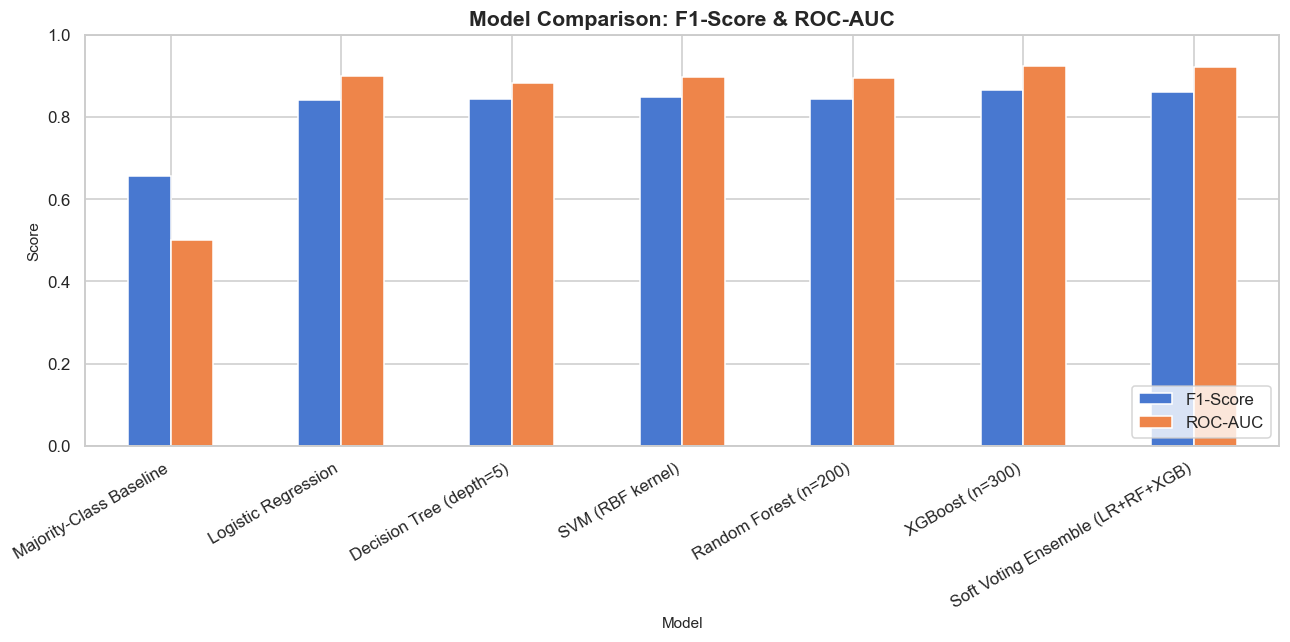

In [17]:
# =============================================================================
# STEP 14 — Final Combined Comparison
# =============================================================================
final_df = pd.DataFrame(all_results).set_index("Model")
print("\n" + "="*70)
print("  COMPLETE MODEL COMPARISON (Work Plans 4 + 6)")
print("="*70)
print(final_df.round(4).to_string())
print("\nPrimary metric: F1-Score (weighted)")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 6))
final_df[["F1-Score", "ROC-AUC"]].plot(kind="bar", ax=ax, edgecolor="white")
ax.set_title("Model Comparison: F1-Score & ROC-AUC", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
